In [82]:
'''
Names: Prashant Ram
Course: CSC 177
Assignment: 1 - Data Preprocessing
Professor: Jagannadha Chidella
Details: This project deals with preprocessing data from a .csv file to ready it for
        data modelling.
'''

import pandas
import matplotlib.pyplot as matPlot
import seaborn

In [6]:
'''
This block reads the data from a .csv file and makes columns for the data
'''
try:
    # import the data from the .csv file. "data" = dataframe
    data = pandas.read_csv('lung_disease_data.csv')

    #print the data attribute columns
    print(data.columns)
        
    # print the number of rows and columns
    print(f'We have {data.shape[0]} rows')
    print(f'We have {data.shape[1]} columns')

    # print the first 5 rows of the data
    print('\n', data.head())
        
except Exception as e:
    print("An error occured while trying to read from the CSV file", e)

Index(['Age', 'Gender', 'Smoking Status', 'Lung Capacity', 'Disease Type',
       'Treatment Type', 'Hospital Visits', 'Recovered'],
      dtype='object')
We have 5200 rows
We have 8 columns

     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
1  34.0  Female            Yes            NaN   Bronchitis        Surgery   
2  80.0    Male            Yes           1.95         COPD            NaN   
3  40.0  Female            Yes            NaN   Bronchitis     Medication   
4  43.0    Male            Yes           4.60         COPD        Surgery   

   Hospital Visits Recovered  
0             14.0       Yes  
1              7.0        No  
2              4.0       Yes  
3              1.0        No  
4              NaN       Yes  


In [7]:
'''
This block counts the number of missing values in each column
'''

#list to hold the columns with missing values
missingColumns = []

try:
    #loop through the columns and get the number of missing values
    for i in data.columns:
        #get the total of column of missing values
        total = data[i].isnull().sum()
        #display the column and the missing values number
        print(f"{i}: {total}")

        #add missing value columns to the list
        if total > 0:
            missingColumns.append(i)

    #finally display which columns had missing values
    print(f"\nThese columns had missing data: {missingColumns}")
    
#catch any reading errors
except Exception as e:
    print("umm. An error occurred while trying to count the missing values..", e)

Age: 300
Gender: 300
Smoking Status: 300
Lung Capacity: 300
Disease Type: 300
Treatment Type: 300
Hospital Visits: 300
Recovered: 300

These columns had missing data: ['Age', 'Gender', 'Smoking Status', 'Lung Capacity', 'Disease Type', 'Treatment Type', 'Hospital Visits', 'Recovered']


In [11]:
'''
This block drops all rows and columns with missing data
'''
# print the number of rows and columns
original_rows = data.shape[0]
original_columns = data.shape[1]
print(f'We have {original_rows} [original] rows and {original_columns} columns')
print('\nOriginal Data:', data.head())
    
#drops all rows with no data
data = data.dropna()

clean_rows = data.shape[0]
clean_columns = data.shape[1]
print(f'\nWe have {clean_rows} [Clean] rows and {clean_columns} columns')
print('\nCleaned data Data:', data.head())

print(f'\n\nWe had {original_rows - clean_rows} rows and {original_columns - clean_columns} columns of missing data')

We have 5200 [original] rows and 8 columns

Original Data:     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
1  34.0  Female            Yes            NaN   Bronchitis        Surgery   
2  80.0    Male            Yes           1.95         COPD            NaN   
3  40.0  Female            Yes            NaN   Bronchitis     Medication   
4  43.0    Male            Yes           4.60         COPD        Surgery   

   Hospital Visits Recovered  
0             14.0       Yes  
1              7.0        No  
2              4.0       Yes  
3              1.0        No  
4              NaN       Yes  

We have 3236 [Clean] rows and 8 columns

Cleaned data Data:     Age  Gender Smoking Status  Lung Capacity Disease Type Treatment Type  \
0  71.0  Female             No           4.49         COPD        Therapy   
5  22.0  Female             No           3.65   Bronchitis     Medication   


In [13]:
'''
This block converts the categorical columns to numeric types so they can be compared
'''
#Convert gender column to numeric
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
print('Gender Column.................DONE')

#Convert Smoking Status Column to Numeric
data['Smoking Status'] = data['Smoking Status'].map({'Yes': 1, 'No': 0})
print('Smoking Status Column.........DONE')

#Convert Recovered Column to Numeric
data['Recovered'] = data['Recovered'].map({'Yes': 1, 'No': 0})
print('Recovered Column..............DONE')

#Convert Disease and Treatment Type Column to Numeric
data = pandas.get_dummies(data, columns=['Disease Type', 'Treatment Type'], drop_first=True)
print('Disease Column................DONE')
print('Treatment Column..............DONE')


Gender Column.................DONE
Smoking Status Column.........DONE
Recovered Column..............DONE
Disease Column................DONE
Treatment Column..............DONE


In [15]:
# Convert boolean columns to integers 1 for True and 0 for False
data = data.astype(int)

#save the dataset using the new split data columns for Disease Type and Treatment Type
try:
    data.to_csv('lung_disease_cleaned.csv', index=False)
    print('Data saved to <<<lung_disease_cleaned.csv>>> with new columns WITHOUT converting TRUE/FALSE values to binary!')
    print('\n', data.head())
except Exception as e:
    print("Couln't save the cleaned data file!")

Data saved to <<<lung_disease_cleaned.csv>>> with new columns WITHOUT converting TRUE/FALSE values to binary!

    Age  Gender  Smoking Status  Lung Capacity  Hospital Visits  Recovered  \
0   71       1               0              4               14          1   
5   22       1               0              3               11          1   
6   41       0               1              2               12          1   
8   21       1               0              4               12          0   
9   49       0               1              5               11          1   

   Disease Type_Bronchitis  Disease Type_COPD  Disease Type_Lung Cancer  \
0                        0                  1                         0   
5                        1                  0                         0   
6                        0                  0                         0   
8                        0                  0                         1   
9                        0                  0     

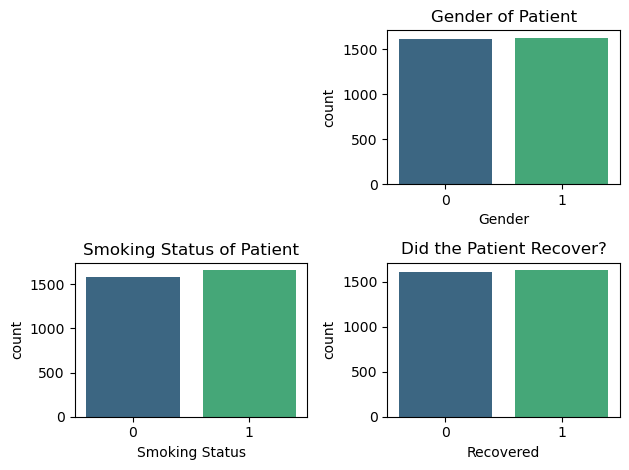

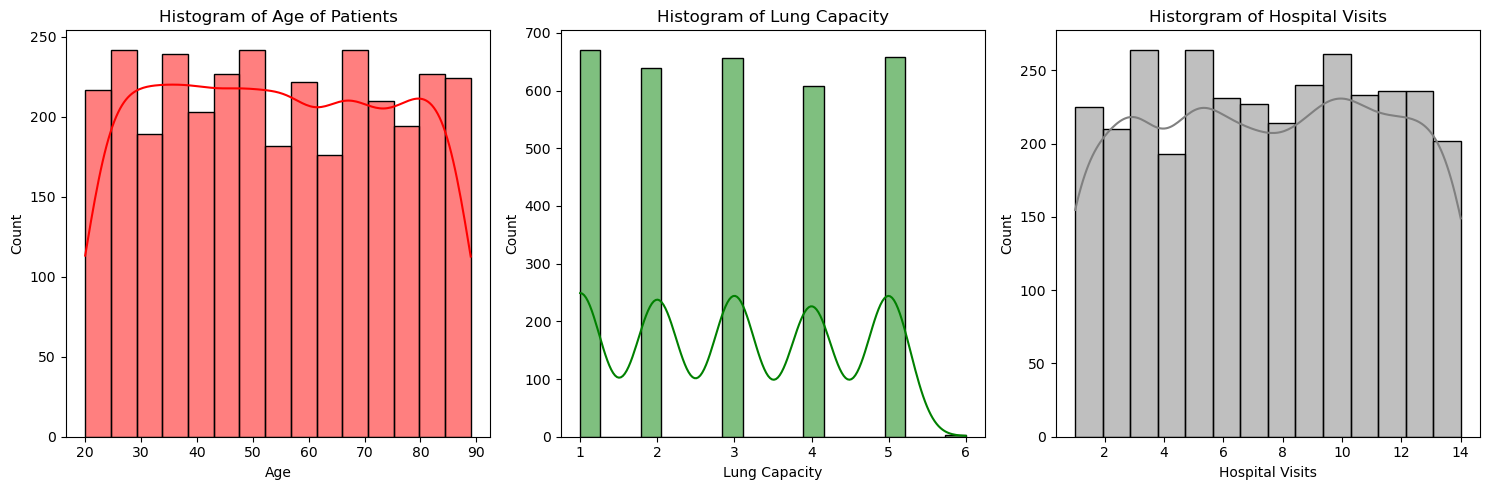

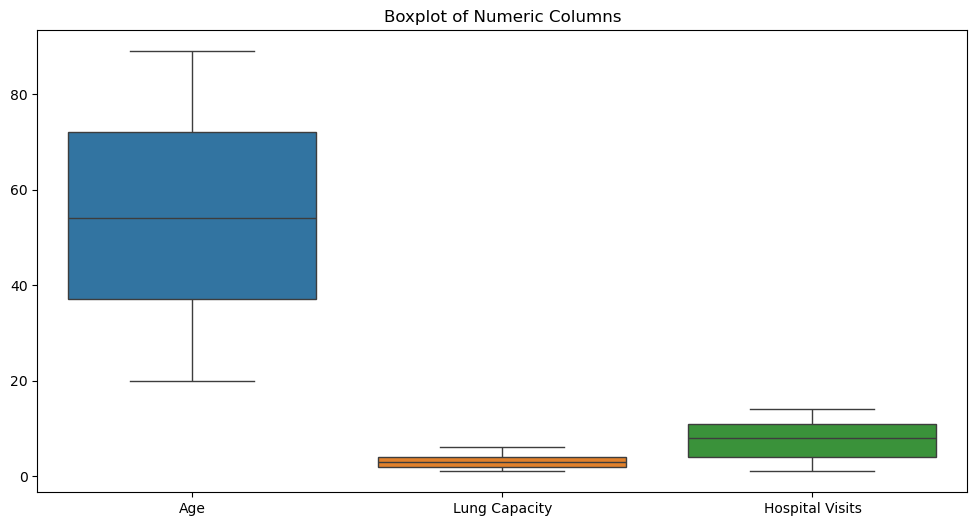

In [62]:
'''
Plots the data from the current dataframe for the individual columns
'''
#plot the Gender column
matPlot.subplot(2,2,2)
seaborn.countplot(x='Gender', data=data, hue='Gender', palette='viridis', legend=False)
matPlot.title('Gender of Patient')

#plot the Smoking Status column
matPlot.subplot(2,2,3)
seaborn.countplot(x='Smoking Status', data=data, hue='Smoking Status', palette='viridis', legend=False)
matPlot.title('Smoking Status of Patient')

#plot the Recovered column
matPlot.subplot(2,2,4)
seaborn.countplot(x='Recovered', data=data, hue='Recovered', palette='viridis', legend=False)
matPlot.title('Did the Patient Recover?')

#make the charts fit nicely together in one window
matPlot.tight_layout()

'''
Histogram plot of numerical columns
'''
# Plot histograms for numerical columns
matPlot.figure(figsize=(15, 5))

# Age
matPlot.subplot(1, 3, 1)
seaborn.histplot(data['Age'], kde=True, color='red')
matPlot.title('Histogram of Age of Patients')

# Lung Capacity
matPlot.subplot(1, 3, 2)
seaborn.histplot(data['Lung Capacity'], kde=True, color='green')
matPlot.title('Histogram of Lung Capacity')

# Hospital Visits
matPlot.subplot(1, 3, 3)
seaborn.histplot(data['Hospital Visits'], kde=True, color='gray')
matPlot.title('Historgram of Hospital Visits')

matPlot.tight_layout()
matPlot.show()

'''
Boxplot of numerical columns
'''
#choose figure size for the plot area
matPlot.figure(figsize=(12, 6))
seaborn.boxplot(data=data[['Age', 'Lung Capacity', 'Hospital Visits']])
matPlot.title("Boxplot of Numeric Columns")
#display the data
matPlot.show()


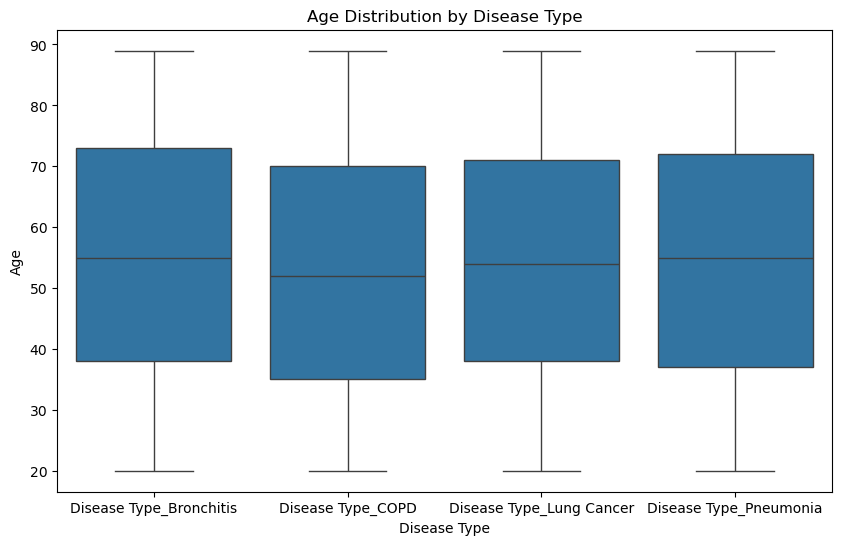

"\nBased on the interpretation above, we can predict that people who suffer from lung diseases majority are in their mid 50's with the older age group\n(greater than 70) suffering from Bronchitis and Pneumonia.\n"

In [86]:
'''
This block plots the Disease columns with the Age column.
'''
#melt the disease type columns into a single column
diseaseTypes = ['Disease Type_Bronchitis', 'Disease Type_COPD', 'Disease Type_Lung Cancer', 'Disease Type_Pneumonia']
data_melted = data.melt(id_vars=['Age'], value_vars=disease_columns, var_name='Disease Type', value_name='Has Disease')

#only get the rows with the disease
data_melted = data_melted[data_melted['Has Disease'] == 1]

#plot the data
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Disease Type', y='Age', data=data_melted)
matPlot.title('Age Distribution by Disease Type')
matPlot.xlabel('Disease Type')
matPlot.ylabel('Age')
matPlot.show()

#Intepretation
'''
It seems that patients suffering from Bronchitis had 1/4 of them of ages between 20 - 38 and the other 1/4 between 74 - 89. The median age 
group (1/2) suffering from this dieases were about 55.
For COPD, the first 1/4 were between 20 -35 and their upper 1/4 were between 70 - 89 while the median age was about 53.
For Lung cancer, the first 1/4 were between 20 -35 and their upper 1/4 were between 70 - 89 while the median age was about 54.
For Pnuemonia, the first 1/4 were between 20 -38 and their upper 1/4 were between 72 - 89 while the median age was about 55.
'''
#Insights
'''
Based on the interpretation above, we can predict that people who suffer from lung diseases majority are in their mid 50's with the older age group
(greater than 70) suffering from Bronchitis and Pneumonia.
'''


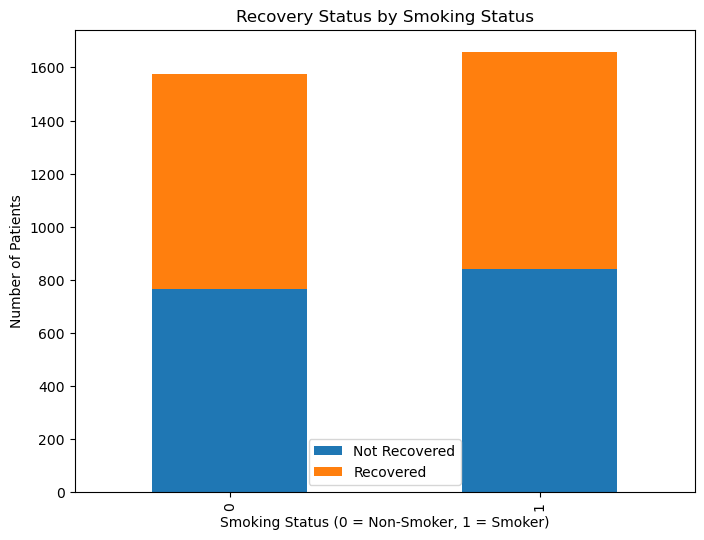

'\nThe insight that we can make from this is that smoking can worsen the recovery outcome of lung diseases.\n'

In [72]:
'''
This block plots the Smoking Status column with the Recovered column.
'''
#group by smoking status and recovery
smoking_recovery = data.groupby(['Smoking Status', 'Recovered']).size().unstack()

#plot the data
smoking_recovery.plot(kind='bar', stacked=True, figsize=(8, 6))
matPlot.title('Recovery Status by Smoking Status')
matPlot.xlabel('Smoking Status (0 = Non-Smoker, 1 = Smoker)')
matPlot.ylabel('Number of Patients')
matPlot.legend(['Not Recovered', 'Recovered'])
matPlot.show()

#Intepretation
'''
The stacked bar graph depicts that patients who were Non-smokers had about similar recovery outcomes as the ones 
who smoked.
However, we can clearly see that Smokers had a higher outcome of not recovering from their lung diseases.
'''
#Insight
'''
The insight that we can make from this is that smoking can worsen the recovery outcome of lung diseases.
'''

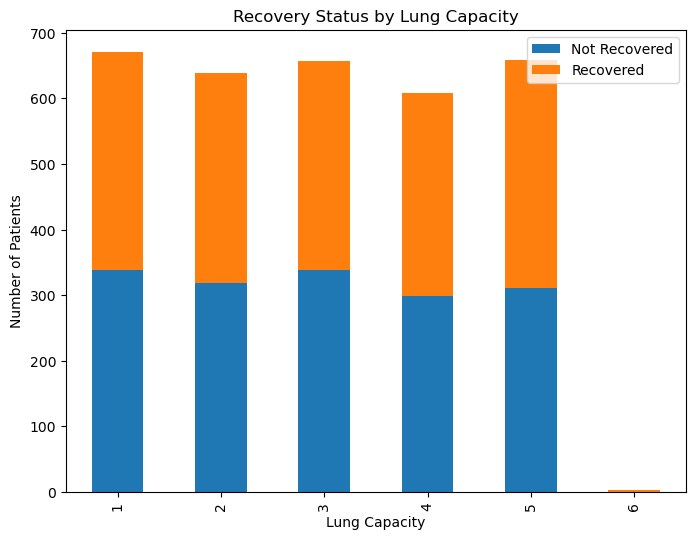

In [55]:
'''
This block plots the Lung Capacity column with the Recovered column.
'''
#group the data by the two columns
lung_capacity_recovery = data.groupby(['Lung Capacity', 'Recovered']).size().unstack()

#plot the data
lung_capacity_recovery.plot(kind='bar', stacked=True, figsize=(8, 6))
matPlot.title('Recovery Status by Lung Capacity')
matPlot.xlabel('Lung Capacity')
matPlot.ylabel('Number of Patients')
matPlot.legend(['Not Recovered', 'Recovered'])
matPlot.show()

#Intepretation
'''
The stacked bar graph depicts that patients who had a lower lung capacity (1, 2 and 3) had higher "Not recovered" count.
Moreover, patients with a high lung capcity (4-5) had about similar ratio of Recovered and Not Recovered. Finally, patients with the highest
lung capacity of 6 had always recovered.
'''
#Insight
'''
The insight that we can make from this is that a lower lung capacity can signicantly reduce the recovery outcomes whereas a a very one can 
almost always guarantee recovery.
'''

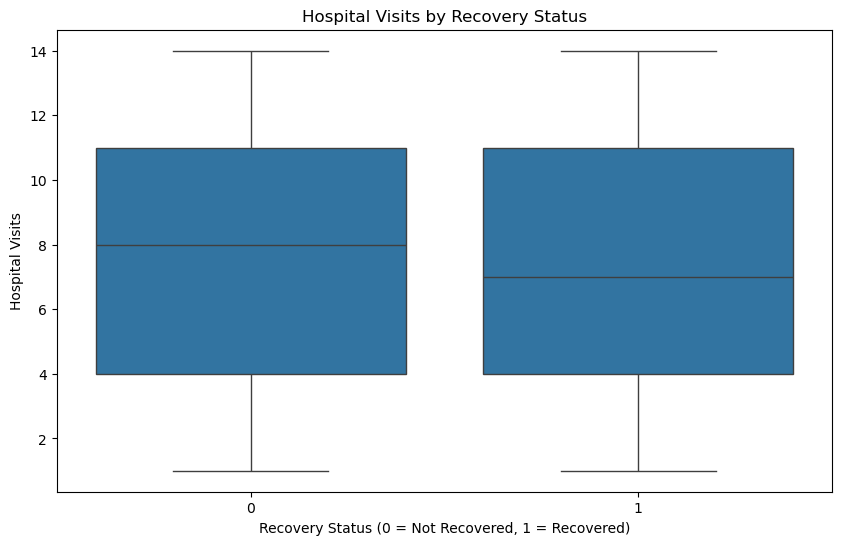

'\nWe can infer from the intepretation above that patients who have a hard time treating their conditions would require more hospital visits.\n'

In [80]:
'''
This block plots the Hospital Visits column with the Recovered column.
'''
#make a boxplot for the two columns.
matPlot.figure(figsize=(10, 6))
seaborn.boxplot(x='Recovered', y='Hospital Visits', data=data)
matPlot.title('Hospital Visits by Recovery Status')
matPlot.xlabel('Recovery Status (0 = Not Recovered, 1 = Recovered)')
matPlot.ylabel('Hospital Visits')
matPlot.show()

#Intepretation
'''
We can see that 1/4 of the patients who had not recovered had hospital visits between 2-4 and the upper 1/4 we between 11-14 visits.
The majority of the patients had about 8 visits.

In contrast, patients who did recover had a median visits of about 7.
'''
#Insight
'''
We can infer from the intepretation above that patients who have a hard time treating their conditions would require more hospital visits.
'''

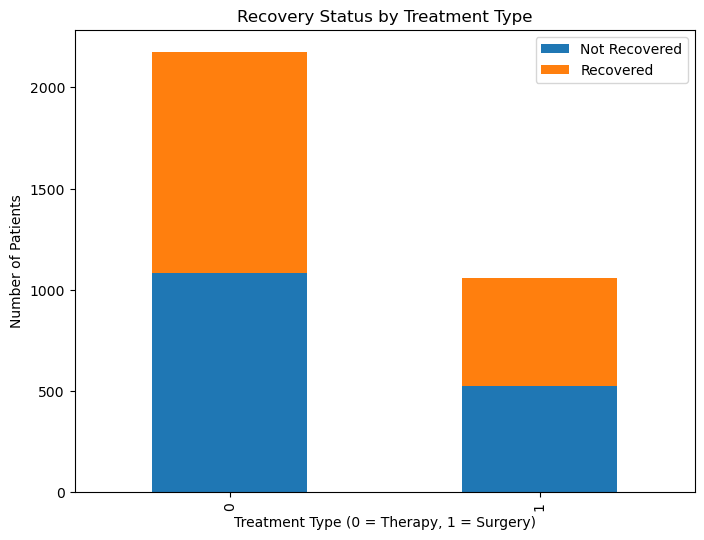

'\nWe can say that surgical forms of treatment work much better than just therapeutical kind.\n'

In [78]:
'''
This block plots the Treatment Types column with the Recovered column.
'''
#group the data by Treatment Type and Recovery
treatment_recovery = data.groupby(['Treatment Type_Surgery', 'Recovered']).size().unstack()

#plot the data
treatment_recovery.plot(kind='bar', stacked=True, figsize=(8, 6))
matPlot.title('Recovery Status by Treatment Type')
matPlot.xlabel('Treatment Type (0 = Therapy, 1 = Surgery)')
matPlot.ylabel('Number of Patients')
matPlot.legend(['Not Recovered', 'Recovered'])
matPlot.show()

#Interpretation
'''
We can see that patients which opted for therapy as theor form of treatment had a higher count of not recovering when compared to the
ones who chose surgery. The ones who chose surgery had a higher count of recovering after the treatment.
'''

#Insight
'''
We can say that surgical forms of treatment work much better than just therapeutical kind.
'''

## Dataset Splitting: Rationale and Statistical Comparison

### Rationale for Splitting
- The dataset was split into **training (80%)** and **testing (20%)** subsets.
- The train-test split is important to allow that the model to be trained on one subset of data and checked on a completely unseen subset.
- By keeping a standard 80-20 split, we ensure that there is enough data for training while preserving a portion for unbiased evaluation.

### Statistical Comparison of Train and Test Sets
- After splitting, we compared parameters such as mean, standard deviation, and distribution of key features to ensure that the split did not introduce any significant biases.
- The describe function was applied separately to both training and test sets to analyze statistics.

### Observations
- The mean and standard deviation of key numerical variables in the training and test sets are similar, confirming that the data split is balanced.
- The proportion of categorical variables (e.g., gender, smoking status) is also maintained between both sets.
- The histogram distributions of continuous features before and after splitting show that the distribution of data remains consistent, validating the split.

### Conclusion
Splitting the dataset correctly ensures that the model generalizes well on unseen data without overfitting. The statistical analysis after the split confirms that the training and test sets represent the original dataset proportionally.
